In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configure analytics stack and shared plotting aesthetics.
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
sns.set_palette("husl")
plt.rcParams["text.color"] = "#222222"

# Data Loading
Load the Kaggle training, test, and sample submission files so every subsequent step operates on consistent inputs.

In [2]:
# Load Kaggle datasets so downstream steps can reuse the same frames.
df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
sub = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")

# Exploratory Data Analysis
Survey distributions, correlations, and missing values to understand the structure of the housing data before modeling.

In [3]:
# Provide a styled preview of the training data to highlight scale differences.
styled_head = (
    df.head()
    .style.set_caption("Training Snapshot")
    .background_gradient(cmap="BuGn", axis=None)
    .format({"SalePrice": "${:,.0f}"})
)
display(styled_head)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000000,8450,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,nan,Attchd,2003.000000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,nan,nan,nan,0,2,2008,WD,Normal,"$208,500"
1,2,20,RL,80.000000,9600,Pave,nan,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,nan,0.000000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,nan,nan,nan,0,5,2007,WD,Normal,"$181,500"
2,3,60,RL,68.000000,11250,Pave,nan,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,nan,nan,nan,0,9,2008,WD,Normal,"$223,500"
3,4,70,RL,60.000000,9550,Pave,nan,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,nan,0.000000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,nan,nan,nan,0,2,2006,WD,Abnorml,"$140,000"
4,5,60,RL,84.000000,14260,Pave,nan,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,nan,nan,nan,0,12,2008,WD,Normal,"$250,000"


In [4]:
# Track numeric fields while ignoring the identifier and target.
numcols = df.describe().columns
numcols_without_id_target = numcols.drop(["Id", "SalePrice"])

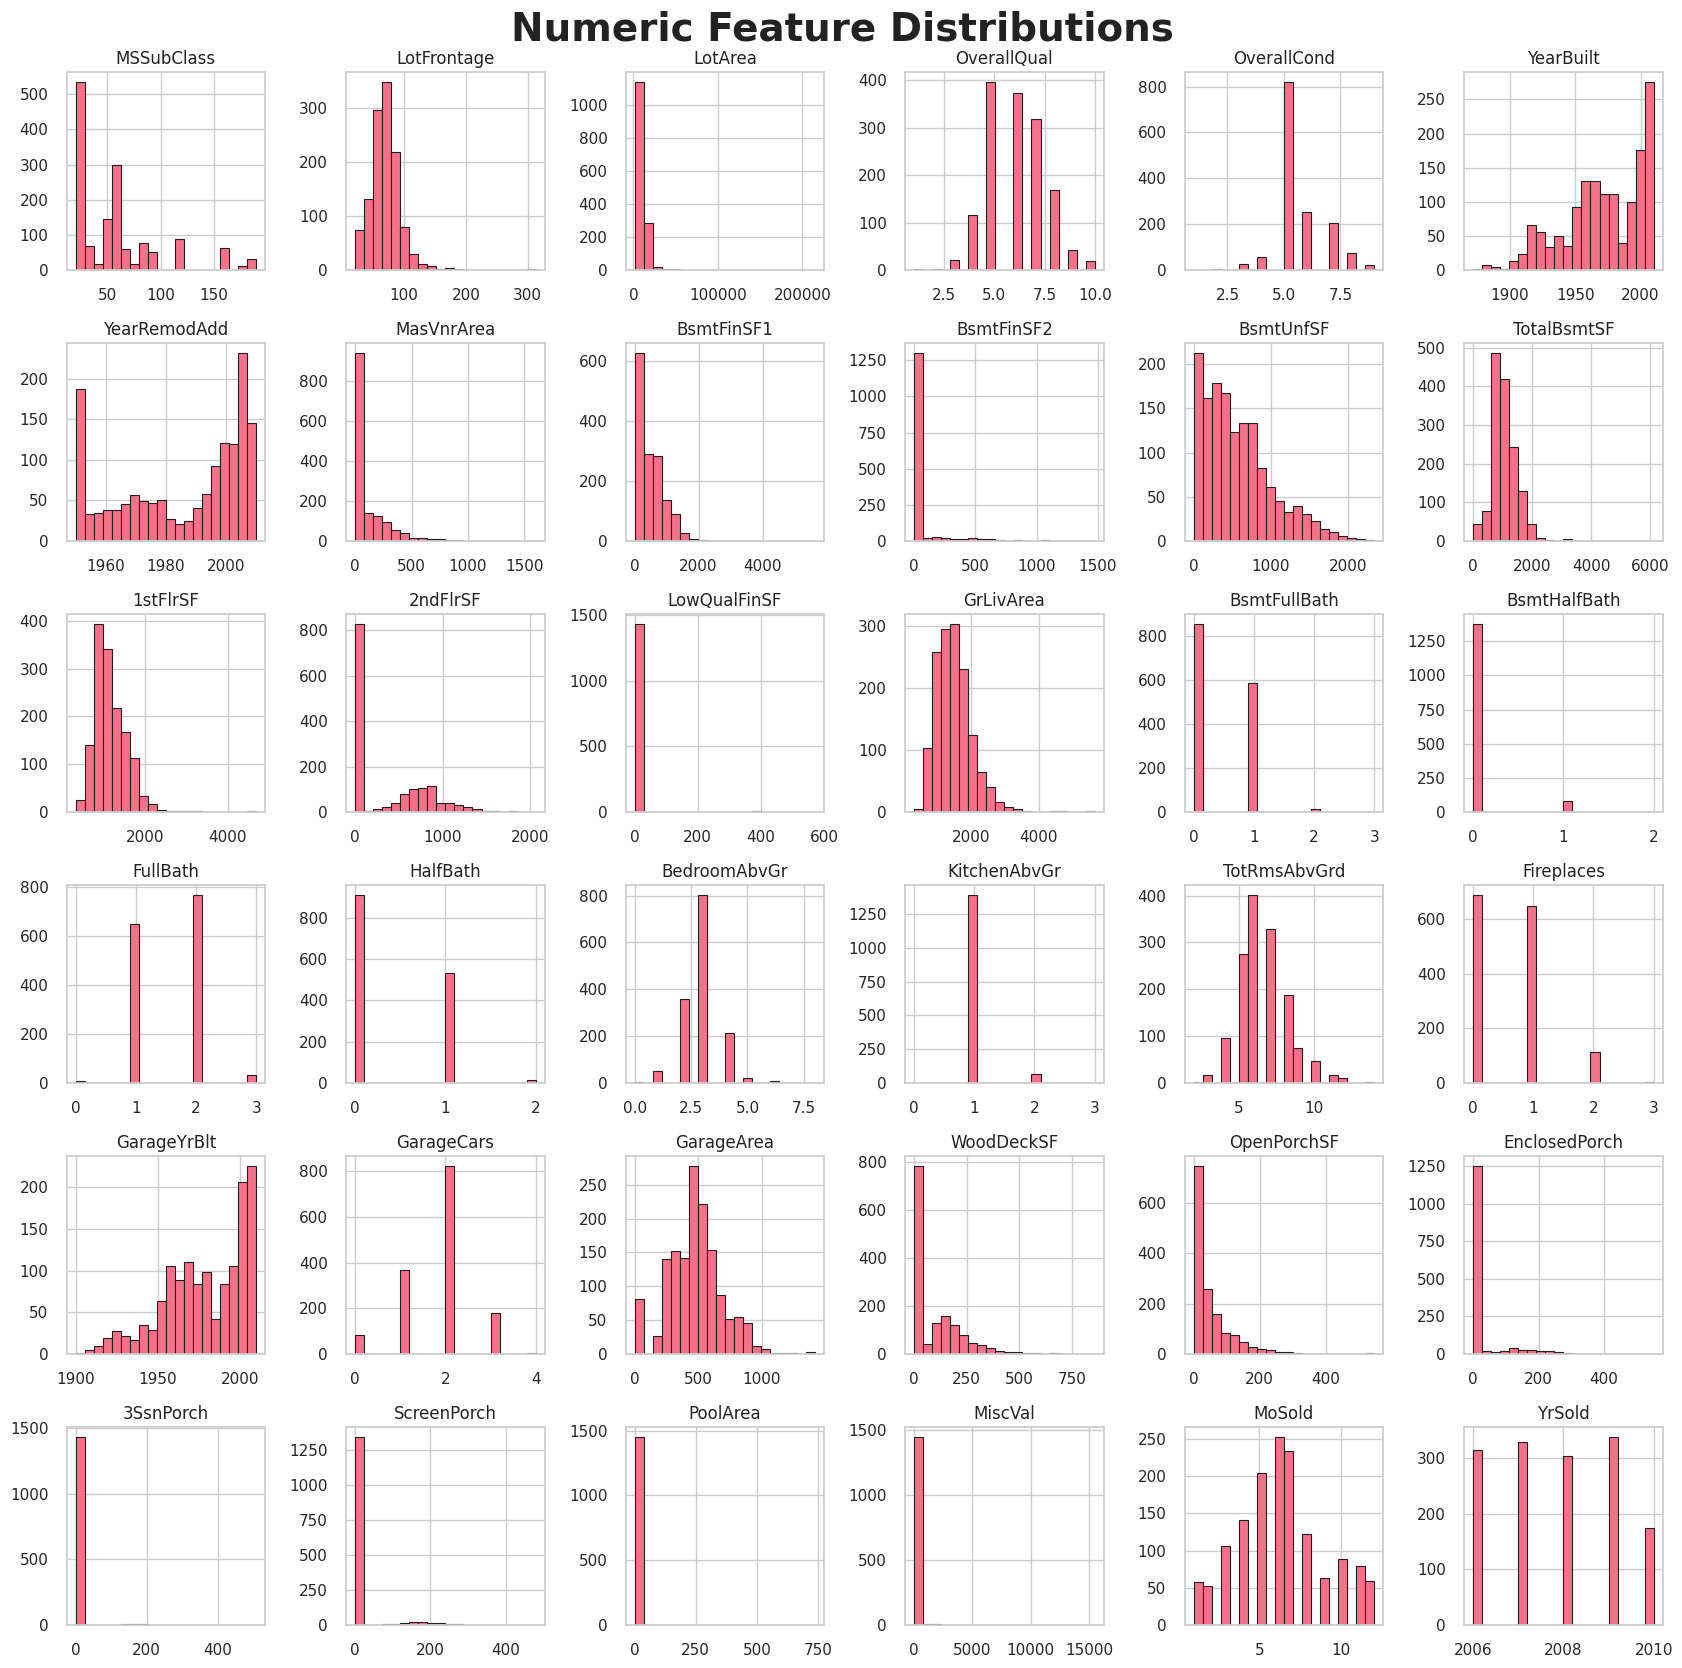

In [5]:
# Visualize each numeric field to quickly spot skewed or wide-spread features.
base_color = sns.color_palette()[0]
df[numcols_without_id_target].hist(bins=20, figsize=(17, 17), color=base_color, edgecolor="#1f1f1f", linewidth=0.8)
plt.suptitle("Numeric Feature Distributions", fontsize=28, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# Review skewness to decide which columns may need transformation.
df[numcols_without_id_target].skew()

MSSubClass        1.407657
LotFrontage       2.163569
LotArea          12.207688
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        2.669084
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
BsmtFullBath      0.596067
BsmtHalfBath      4.103403
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      4.488397
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.649415
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
MoSold            0.212053
YrSold            0.096269
dtype: float64

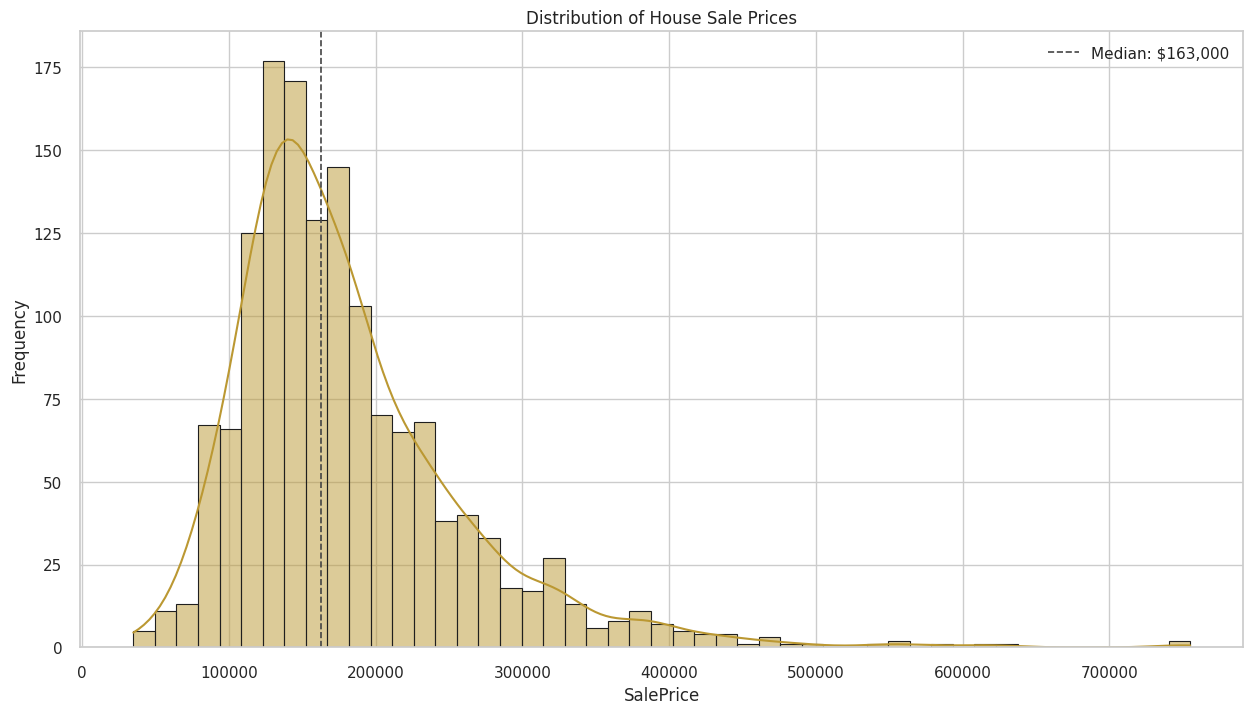

In [7]:
# Inspect the sale price distribution with a quick median reference line.
fig, ax = plt.subplots(figsize=(15, 8))
sns.histplot(df["SalePrice"], kde=True, color=sns.color_palette()[1], edgecolor="#1f1f1f", linewidth=0.8, ax=ax)
median_price = df["SalePrice"].median()
ax.axvline(median_price, color="#444444", linestyle="--", linewidth=1.2, label=f"Median: ${median_price:,.0f}")
ax.set(title="Distribution of House Sale Prices", xlabel="SalePrice", ylabel="Frequency")
ax.legend()
plt.show()

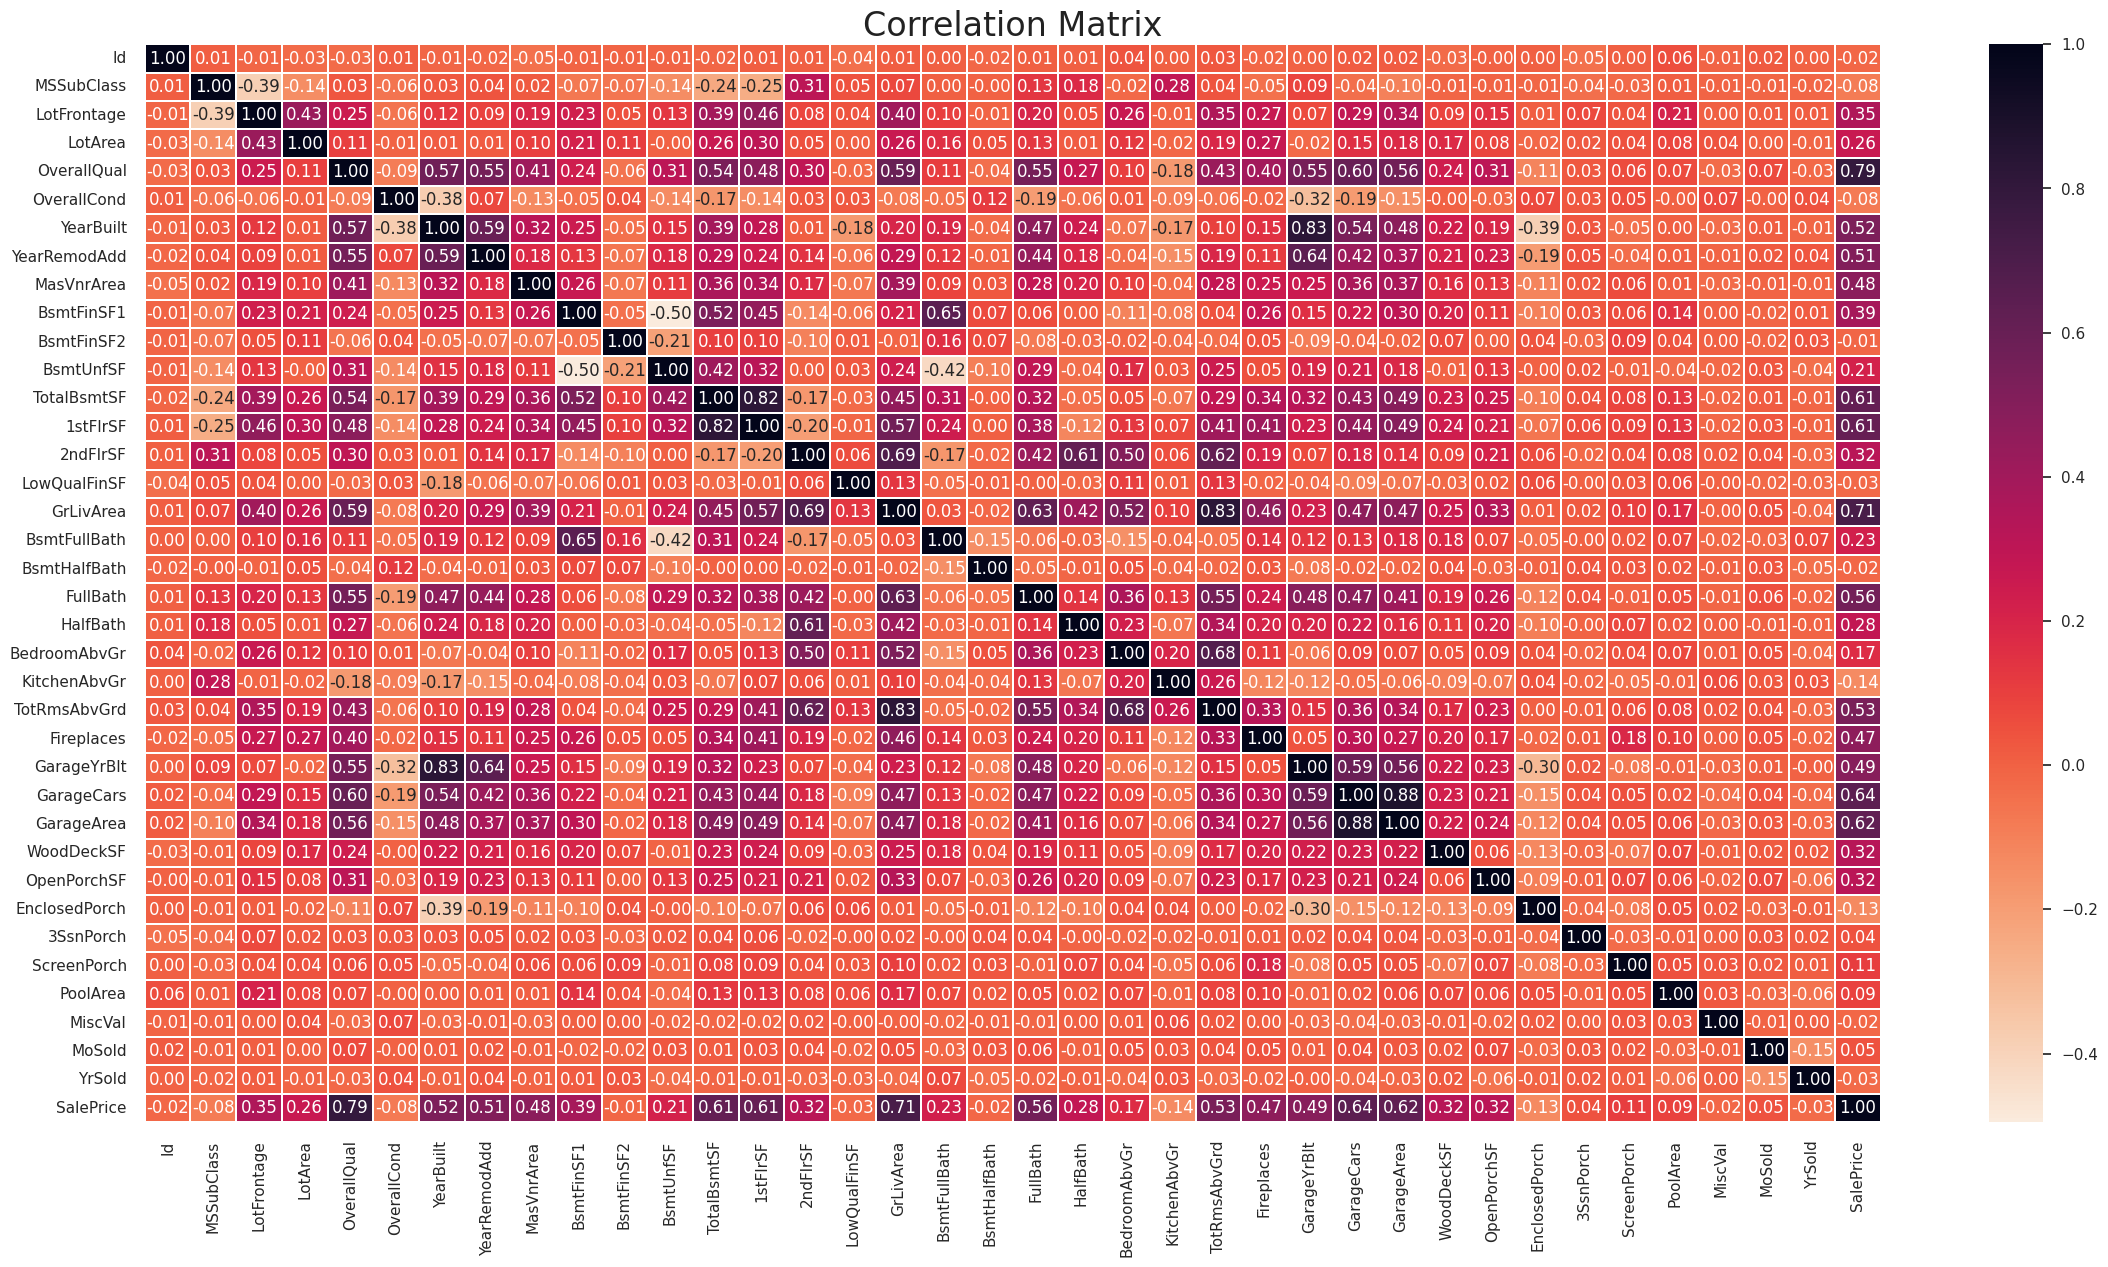

In [8]:
# Correlate numeric features to highlight which ones align with SalePrice.
plt.figure(figsize=(28, 14))
corr = df[numcols].corr()
sns.heatmap(corr, annot=True, cmap="rocket_r", fmt=".2f", linewidths=0.2)
plt.title("Correlation Matrix", fontsize=24)
plt.show()

In [9]:
# Quantify columns with missing data as percentages for prioritizing imputations.
df.isna().sum()[df.isna().sum() > 0] / len(df) * 100

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

# Feature Engineering
Introduce derived attributes such as property age, total square footage, and amenity indicators to provide richer signals.

In [10]:
from sklearn.preprocessing import FunctionTransformer

drop_cols = ["Id", "Alley", "PoolQC", "Fence", "MiscFeature"]

# Feature-engineering helper that adds composite areas, ages, and amenity flags.
def added_features(df):
    df_out = df.copy()
    df_out = df_out.drop(columns=drop_cols, errors="ignore")

    df_out["PropertyAge"] = df_out["YrSold"] - df_out["YearBuilt"]
    df_out["TotalSF"] = df_out["TotalBsmtSF"] + df_out["1stFlrSF"] + df_out["2ndFlrSF"]
    df_out["TotalBath"] = (
        df_out["FullBath"]
        + 0.5 * df_out["HalfBath"]
        + df_out["BsmtFullBath"]
        + 0.5 * df_out["BsmtHalfBath"]
    )

    df_out["HasRemodeled"] = (df_out["YearRemodAdd"] != df_out["YearBuilt"]).astype(object)
    df_out["HasPool"] = (df_out["PoolArea"] > 0).astype(int)
    df_out["HasBasement"] = (df_out["TotalBsmtSF"] > 0).astype(int)
    df_out["HasFireplace"] = (df_out["Fireplaces"] > 0).astype(int)
    df_out["Has2ndFloor"] = (df_out["2ndFlrSF"] > 0).astype(object)
    df_out["HasGarage"] = (df_out["GarageArea"] > 0).astype(object)

    df_out["YrSold_cat"] = df_out["YrSold"].astype(object)
    df_out["MoSold_cat"] = df_out["MoSold"].astype(object)
    df_out["YearBuilt_cat"] = df_out["YearBuilt"].astype(object)
    df_out["MSSubClass_cat"] = df_out["MSSubClass"].astype(object)

    df_out["OverallGrade"] = df_out["OverallQual"] * df_out["OverallCond"]
    df_out["QualityArea"] = df_out["OverallQual"] * df_out["GrLivArea"]

    return df_out

feature_transformer = FunctionTransformer(added_features)

# Preprocessing Pipelines
Define column-wise imputers, encoders, and scalers so engineered features are ready for any downstream estimator.

In [11]:
# Extend dtype-driven column splits with engineered fields for the transformer.
new_cols_categorical = pd.Index([
    "HasRemodeled","Has2ndFloor","HasGarage","YrSold_cat","MoSold_cat","YearBuilt_cat","MSSubClass_cat"
])
new_cols_numeric = pd.Index([
    "PropertyAge","TotalSF","TotalBath","HasFireplace","HasBasement","HasPool","OverallGrade","QualityArea"
])

base_categorical = df.select_dtypes(include=["object", "category"]).columns.difference(drop_cols)
base_numerical = df.select_dtypes(include=["int64", "float64"]).columns.difference(drop_cols + ["SalePrice"])
categorical_columns = base_categorical.append(new_cols_categorical)
numerical_columns = base_numerical.append(new_cols_numeric)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define imputation and scaling steps tailored for categorical vs. numeric groups.
cat_transform = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
    ]
)
num_transform = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

In [13]:
# Blend feature engineering with ColumnTransformer preprocessing to prep model inputs.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transform, categorical_columns),
        ("num", num_transform, numerical_columns),
    ],
    remainder="passthrough",
)
pipeline = Pipeline([
    ("engineer", feature_transformer),
    ("preprocessor", preprocessor),
])

X = df.drop("SalePrice", axis=1)
y = np.log(df["SalePrice"])
X_preprocessed = pipeline.fit_transform(X)
test_preprocessed = pipeline.transform(test)

In [14]:
# Bring in core model families plus Optuna for hyperparameter tuning.
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, ElasticNet, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge
import optuna

# Hyperparameter Tuning with Optuna
Set up study objectives for each base learner so we can search for low-RMSE configurations in a consistent way.

In [15]:
# Collect objective functions for each learner so Optuna can tune them consistently.
objectives = {}

def objective_lgbm(trial):
    params = {
        "n_estimators": 1000,
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", -1, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    score = -cross_val_score(model, X_preprocessed, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["LightGBM"] = objective_lgbm

def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=132)
    score = -cross_val_score(model, X_preprocessed, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["Ridge"] = objective_ridge

def objective_elastic(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=132, max_iter=20000)
    score = -cross_val_score(model, X_preprocessed, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["ElasticNet"] = objective_elastic

def objective_krr(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "polynomial", "rbf"])
    if kernel == "polynomial":
        degree = trial.suggest_int("degree", 2, 5)
        coef0 = trial.suggest_float("coef0", 0.0, 5.0)
        model = KernelRidge(alpha=alpha, kernel=kernel, degree=degree, coef0=coef0)
    else:
        model = KernelRidge(alpha=alpha, kernel=kernel)
    score = -cross_val_score(model, X_preprocessed, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["KernelRidge"] = objective_krr

def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42,
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }
    model = XGBRegressor(**params)
    score = -cross_val_score(model, X_preprocessed, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return score
objectives["XGBoost"] = objective_xgb

In [16]:
# Execute a short Optuna sweep for every learner and capture the best scores/params.
best_params = {}
best_scores = {}

for name, objective in objectives.items():
    print(f"\nOptimizing {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5, show_progress_bar=True)
    best_params[name] = study.best_params
    best_scores[name] = study.best_value
    print(f"{name} best RMSE: {study.best_value:.5f}")
    print(f"Best params: {study.best_params}")

[I 2025-11-17 16:06:49,335] A new study created in memory with name: no-name-fa3f565b-be97-497d-bb31-1844744f5f6c



Optimizing LightGBM...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-17 16:06:54,436] Trial 0 finished with value: 0.12672587488932377 and parameters: {'learning_rate': 0.045142204855196835, 'num_leaves': 26, 'max_depth': 7, 'subsample': 0.5862611127193447, 'colsample_bytree': 0.7102422304019943, 'reg_alpha': 0.027261342598532336, 'reg_lambda': 0.0008971892890419283}. Best is trial 0 with value: 0.12672587488932377.
[I 2025-11-17 16:06:55,445] Trial 1 finished with value: 0.2238966504408444 and parameters: {'learning_rate': 0.002256304732225325, 'num_leaves': 225, 'max_depth': 1, 'subsample': 0.7355726595611377, 'colsample_bytree': 0.862445142033447, 'reg_alpha': 0.0005201641848059723, 'reg_lambda': 0.012391469064209607}. Best is trial 0 with value: 0.12672587488932377.
[I 2025-11-17 16:07:04,949] Trial 2 finished with value: 0.1292164522041818 and parameters: {'learning_rate': 0.0198328443482694, 'num_leaves': 89, 'max_depth': 13, 'subsample': 0.6856470004580912, 'colsample_bytree': 0.9038654272460437, 'reg_alpha': 0.1759409446028849, 'reg_l

[I 2025-11-17 16:07:08,869] A new study created in memory with name: no-name-1623f158-ef8f-4897-be0f-9481ec011a5a


...

[I 2025-11-17 16:07:14,978] Trial 0 finished with value: 0.375126791903906 and parameters: {'alpha': 0.001978135729728376, 'kernel': 'rbf'}. Best is trial 0 with value: 0.375126791903906.
[I 2025-11-17 16:07:15,548] Trial 1 finished with value: 0.1658194427012041 and parameters: {'alpha': 0.008556551820696312, 'kernel': 'linear'}. Best is trial 1 with value: 0.1658194427012041.
[I 2025-11-17 16:07:16,132] Trial 2 finished with value: 0.16221068465700197 and parameters: {'alpha': 0.061246701742544825, 'kernel': 'linear'}. Best is trial 2 with value: 0.16221068465700197.
[I 2025-11-17 16:07:17,028] Trial 3 finished with value: 0.1433077728860823 and parameters: {'alpha': 0.05244690317382275, 'kernel': 'polynomial', 'degree': 4, 'coef0': 4.297812484297105}. Best is trial 3 with value: 0.1433077728860823.


[I 2025-11-17 16:07:17,617] A new study created in memory with name: no-name-da30e62c-82eb-4010-8f05-0ca0e8a8fa98


[I 2025-11-17 16:07:17,610] Trial 4 finished with value: 0.16216682795753032 and parameters: {'alpha': 0.06208875546147495, 'kernel': 'linear'}. Best is trial 3 with value: 0.1433077728860823.
KernelRidge best RMSE: 0.14331
Best params: {'alpha': 0.05244690317382275, 'kernel': 'polynomial', 'degree': 4, 'coef0': 4.297812484297105}

Optimizing XGBoost...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-17 16:07:25,193] Trial 0 finished with value: 0.15844758198877112 and parameters: {'max_depth': 3, 'learning_rate': 0.00214874127800653, 'subsample': 0.9309663895372435, 'colsample_bytree': 0.9928953480375728, 'reg_alpha': 0.004731110489430666, 'reg_lambda': 0.04278308996942671}. Best is trial 0 with value: 0.15844758198877112.
[I 2025-11-17 16:07:33,980] Trial 1 finished with value: 0.11885437777198012 and parameters: {'max_depth': 4, 'learning_rate': 0.018299404360135003, 'subsample': 0.8373384926610358, 'colsample_bytree': 0.8905456310877524, 'reg_alpha': 0.0009055215166824951, 'reg_lambda': 0.04408775432396811}. Best is trial 1 with value: 0.11885437777198012.
[I 2025-11-17 16:07:50,313] Trial 2 finished with value: 0.12924875279926365 and parameters: {'max_depth': 9, 'learning_rate': 0.09100534737612007, 'subsample': 0.7888118170658163, 'colsample_bytree': 0.9664847410239263, 'reg_alpha': 0.00030711234980851425, 'reg_lambda': 3.9728874452875598}. Best is trial 1 with va

## Optuna Study Output
Verbose Optuna trial logs are collapsed here; expand the cell output if you need to inspect individual trial diagnostics.

In [17]:
# Persist the best-performing configurations from the extended Optuna search.
best_params_dict = {
    "Ridge": {"alpha": 6.577845021836757},
    "ElasticNet": {
        "alpha": 0.001175898057027851,
        "l1_ratio": 0.2556675520546301,
    },
    "KernelRidge": {
        "alpha": 0.1476316691169565,
        "kernel": "polynomial",
        "degree": 2,
        "coef0": 2.082659943772578,
    },
    "XGBoost": {
        "max_depth": 4,
        "learning_rate": 0.02373014388999918,
        "subsample": 0.8423921813587263,
        "colsample_bytree": 0.5228354076316597,
        "reg_alpha": 0.00014172841523401867,
        "reg_lambda": 0.008005196902006313,
    },
    "LightGBM": {
        "learning_rate": 0.06234817414958063,
        "num_leaves": 278,
        "max_depth": 2,
        "subsample": 0.593312100941863,
        "colsample_bytree": 0.7497991100268827,
        "reg_alpha": 0.0001354219967120134,
        "reg_lambda": 5.097599798916927,
        "verbose": -1,
    },
}

# Train Tuned Base Models
Instantiate each tuned estimator and capture out-of-fold predictions that will later feed the meta-model.

In [18]:
# Instantiate each learner with the tuned hyperparameters for downstream CV.
tuned_models = [
    ("Ridge", Ridge(**best_params_dict["Ridge"], random_state=132)),
    ("ElasticNet", ElasticNet(**best_params_dict["ElasticNet"], random_state=132, max_iter=20000)),
    ("KernelRidge", KernelRidge(**best_params_dict["KernelRidge"])),
    ("XGBoost", XGBRegressor(**best_params_dict["XGBoost"], random_state=132)),
    ("LightGBM", LGBMRegressor(**best_params_dict["LightGBM"], random_state=132)),
]

In [19]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
oof_preds = {name: np.zeros(len(X)) for name, _ in tuned_models}

# Fit each tuned model with OOF folds to capture predictions for stacking.
for name, model in tuned_models:
    print(f"Training tuned model: {name}")
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_preprocessed, y), 1):
        X_tr, X_val = X_preprocessed[tr_idx], X_preprocessed[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        oof_preds[name][val_idx] = preds
    rmse = np.sqrt(mean_squared_error(y, oof_preds[name]))
    print(f"{name} OOF RMSE: {rmse:.5f}")

Training tuned model: Ridge
Ridge OOF RMSE: 0.13827
Training tuned model: ElasticNet
ElasticNet OOF RMSE: 0.13770
Training tuned model: KernelRidge
KernelRidge OOF RMSE: 0.12179
Training tuned model: XGBoost
XGBoost OOF RMSE: 0.14389
Training tuned model: LightGBM
LightGBM OOF RMSE: 0.13821


# Stacking Meta-Model
Train an ElasticNet meta-learner on the out-of-fold predictions to blend the strengths of the base models.

In [20]:
X_meta = pd.DataFrame(oof_preds)

# Optuna objective for the ElasticNet meta-learner tuned on OOF predictions.
def objective_meta(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    meta_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=20000)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)
    for tr_idx, val_idx in kf.split(X_meta):
        X_tr, X_val = X_meta.iloc[tr_idx], X_meta.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        meta_model.fit(X_tr, y_tr)
        preds[val_idx] = meta_model.predict(X_val)
    score = np.sqrt(mean_squared_error(y, preds))
    return score

study = optuna.create_study(direction="minimize")
study.optimize(objective_meta, n_trials=150, show_progress_bar=True)

[I 2025-11-17 16:08:37,132] A new study created in memory with name: no-name-962387ee-5241-49e9-b12e-db7eb58b25d9


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2025-11-17 16:08:37,173] Trial 0 finished with value: 0.12256586742365183 and parameters: {'alpha': 0.00011304346992221562, 'l1_ratio': 0.28834387554552143}. Best is trial 0 with value: 0.12256586742365183.
[I 2025-11-17 16:08:37,192] Trial 1 finished with value: 0.12609655688848273 and parameters: {'alpha': 0.02577500848538461, 'l1_ratio': 0.09478001230017774}. Best is trial 0 with value: 0.12256586742365183.
[I 2025-11-17 16:08:37,212] Trial 2 finished with value: 0.31195462434567756 and parameters: {'alpha': 0.17089045444021686, 'l1_ratio': 0.6012531777455421}. Best is trial 0 with value: 0.12256586742365183.
[I 2025-11-17 16:08:37,233] Trial 3 finished with value: 0.14426599780978386 and parameters: {'alpha': 0.029208593993503774, 'l1_ratio': 0.8772386976508824}. Best is trial 0 with value: 0.12256586742365183.
[I 2025-11-17 16:08:37,255] Trial 4 finished with value: 0.1507376881861048 and parameters: {'alpha': 0.05664617340086511, 'l1_ratio': 0.4465920238132379}. Best is trial 

In [21]:
# Surface the best score and parameters from the meta-model study.
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.12206144993744716
Best params: {'alpha': 0.0004343218340105772, 'l1_ratio': 0.9988599850725922}


In [22]:
# Finalize the meta-model using the optimal hyperparameters and score on training data.
best_meta = ElasticNet(**study.best_params, random_state=42, max_iter=20000)
best_meta.fit(X_meta, y)
meta_pred = best_meta.predict(X_meta)
meta_rmse = np.sqrt(mean_squared_error(y, meta_pred))
print(f"Final Meta-model RMSE: {meta_rmse:.5f}")

Final Meta-model RMSE: 0.11937


# Final Prediction and Submission
Generate meta-level predictions for the held-out test data and write a Kaggle-ready submission file.

In [23]:
# Build meta-level predictions for the test set and output a styled submission preview.
test_meta = pd.DataFrame({name: model.predict(test_preprocessed) for name, model in tuned_models})
stack_pred = best_meta.predict(test_meta)
final_pred = np.expm1(stack_pred)

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": final_pred})
submission.to_csv("submission.csv", index=False)

print("Submission file created: submission.csv")
styled_preview = submission.head().style.format({"SalePrice": lambda v: f"${v:,.0f}"}).background_gradient(cmap="Blues", subset=["SalePrice"])
display(styled_preview)

Submission file created: submission.csv


,Id,SalePrice
0,1461,"$117,204"
1,1462,"$155,383"
2,1463,"$177,654"
3,1464,"$193,271"
4,1465,"$189,360"
